In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd

import h3

from ev_sim.shapely import *
from ev_sim.distance import distance

In [3]:
ANN_ARBOR_ISLAND = {"type": "Polygon", "coordinates": [
    [[-83.78417372229106, 42.2816895426656], [-83.78442833090553, 42.26436540031527],
     [-83.78280893765309, 42.26008492559868], [-83.75582454773287, 42.23979620799212],
     [-83.74883466508147, 42.236735929136465], [-83.73855136330737, 42.23687482780095],
     [-83.71183498245512, 42.23740370837849], [-83.70811584123601, 42.23621391164227],
     [-83.68529280749691, 42.22525665336085], [-83.6857906858808, 42.23650010597878],
     [-83.6835321940817, 42.242004706064414], [-83.68404965774359, 42.25791215499742],
     [-83.68344560653675, 42.260914190143346], [-83.67688247678568, 42.26649675626558],
     [-83.67600732409866, 42.2715448988836], [-83.67658457439869, 42.28632696416514],
     [-83.67755868428011, 42.290614044749944], [-83.68167983910097, 42.2936145225612],
     [-83.686552450116, 42.297851548528804], [-83.68752346758508, 42.30527118507393],
     [-83.68752346758508, 42.311899477555414], [-83.68815019648227, 42.3176894192593],
     [-83.68965620128301, 42.321647402227995], [-83.69600286217157, 42.32340566372425],
     [-83.70765507180005, 42.32404585076619], [-83.72079679336368, 42.322860737478855],
     [-83.7330180068595, 42.32077168278856], [-83.73966360093908, 42.318253445137586],
     [-83.7425591296764, 42.31203821066514], [-83.7442414019795, 42.30786083796349],
     [-83.74416924569199, 42.30552504742622], [-83.74739360093946, 42.30038356346508],
     [-83.75116943638452, 42.29796820186064], [-83.76443176202858, 42.29866354272832],
     [-83.77387186604301, 42.30072283505719], [-83.78112975776224, 42.300962992494966],
     [-83.78872163001232, 42.29782791286006], [-83.79392203673349, 42.29357716043808],
     [-83.79792464908206, 42.290636920597954], [-83.80538664001456, 42.289349759963734],
     [-83.81290944838942, 42.28866651709263], [-83.79942756147045, 42.286966765791036],
     [-83.78751558920678, 42.284564616433606], [-83.78417372229106, 42.2816895426656]]]}

INTERCHANGES = [[-83.76428663584798, 42.24621291273493],
                [-83.73925818685441, 42.23706478179984],
                [-83.6856605166818, 42.225870502706016],
                [-83.68419888669358, 42.25478224069996],
                [-83.68758426002664, 42.30651664045945],
                [-83.74775152489084, 42.30070994562671],
                [-83.78733791729108, 42.29845959088495]]

OVERPASSES = [[-83.72025577918251, 42.23733842449474],
              [-83.69982464756285, 42.23235080877966],
              [-83.68561373145211, 42.230665232047656],
              [-83.68367416728648, 42.24553029362142],
              [-83.68273945396665, 42.2946569263457],
              [-83.70794793789851, 42.32405213628119],
              [-83.7354451631902, 42.319908790932466],
              [-83.76593721277933, 42.299095030528555],
              [-83.79970137211885, 42.29041832301253],
              [-83.78396890830167, 42.281680090237515],
              [-83.78442376681384, 42.27278069052162],
              [-83.77717033537063, 42.25620047726419]]

AM_PEAK = 592  # 7am - 10am
MIDDAY = 593  # 10am - 3pm
PM_PEAK = 594  # 3pm - 7pm
OFF_PEAK = 595  # 7pm - 7am

WEEKDAY = 1
SATURDAY = 2
SUNDAY = 3

In [4]:
def sample_semcog_data(df: pd.DataFrame, gdf: pd.DataFrame) -> pd.DataFrame:
    # merge geojson dataframe to semcog data
    n_external = ((df["origin_tract"] == -1) + (df["destination_tract"] == -1)).sum()

    n = len(df)
    df = df.merge(gdf[["geoId", "lon_min", "lat_min", "lon_max", "lat_max"]],
                  left_on="origin_tract", right_on="geoId", how="inner")
    df = df.merge(gdf[["geoId", "lon_min", "lat_min", "lon_max", "lat_max"]],
                  left_on="destination_tract", right_on="geoId", how="inner", suffixes=("_pick", "_drop"))
    assert n - n_external == len(df), f"Dropped {n - len(df)} of {len(df)} rows when merging zone data to trips"

    # sample times
    df["start_time"] = df["time_of_day"].map({AM_PEAK: 7, MIDDAY: 10, PM_PEAK: 15, OFF_PEAK: 19})
    df["end_time"] = df["time_of_day"].map({AM_PEAK: 10, MIDDAY: 15, PM_PEAK: 19, OFF_PEAK: 31})  # 31:00 mod 24 = 7 AM
    df["start_time"] *= 3600  # convert to seconds
    df["end_time"] *= 3600  # convert to seconds

    # split df into weekend and weekday, then repeat weekday df once for each weekday (0, ..., 4)
    weekday_df = df[df["wday_type"] == WEEKDAY]
    weekend_df = df[df["wday_type"] != WEEKDAY]
    weekday_df = weekday_df.loc[weekday_df.index.repeat(5)].copy()  # repeat df once for each weekday
    # set wday_type to (0, 1, 2, 3, 4) repeated
    weekday_df["wday_type"] = np.tile(np.arange(0, 5), sum(df["wday_type"] == WEEKDAY))

    weekend_df.loc[:, "wday_type"] = weekend_df["wday_type"].map({SATURDAY: 5, SUNDAY: 6})
    df = pd.concat([weekday_df, weekend_df], ignore_index=True)  # combine weekend & weekday dfs

    # sample number of daily trips from a Poisson distribution with mean daily_trips
    rng = np.random.default_rng()
    df["trips"] = rng.poisson(df["daily_trips"])
    df = df.reindex(df.index.repeat(df["trips"]))

    # sample trip start times
    df["created_at"] = np.random.uniform(df["start_time"], df["end_time"])
    df["created_at"] %= 24 * 3600  # modulo 24 hours
    df["created_at"] += 24 * 3600 * df["wday_type"]
    df["created_at"] = df["created_at"].astype("uint32")

    df["pick_lat"] = np.random.uniform(low=df["lat_min_pick"], high=df["lat_max_pick"]).astype("float32")
    df["pick_lon"] = np.random.uniform(low=df["lon_min_pick"], high=df["lon_max_pick"]).astype("float32")
    df["drop_lat"] = np.random.uniform(low=df["lat_min_drop"], high=df["lat_max_drop"]).astype("float32")
    df["drop_lon"] = np.random.uniform(low=df["lon_min_drop"], high=df["lon_max_drop"]).astype("float32")

    df["pax"] = np.random.choice(np.arange(1, 6, dtype="uint8"), size=len(df), p=[0.775, 0.15, 0.04, 0.02, 0.015])

    df.drop(["origin_bg", "destination_bg", "geoId_pick", "geoId_drop",
             "origin_tract", "destination_tract",
             "distance_mi", "daily_pmt", "daily_trips", "trips",
             "wday_type", "start_time", "end_time", "time_of_day",
             "lon_min_pick", "lat_min_pick", "lon_max_pick", "lat_max_pick",
             "lon_min_drop", "lat_min_drop", "lon_max_drop", "lat_max_drop"], axis=1, inplace=True, errors="ignore")

    return df

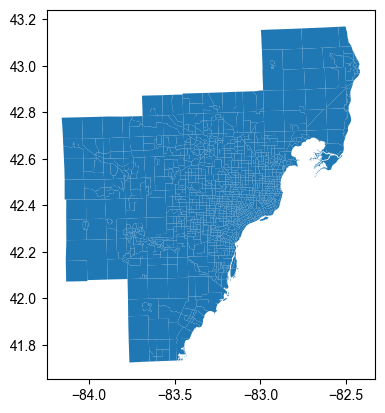

In [5]:
REGION = "se-michigan"

gdf = gpd.read_file("data/semcog/2020_Census_Tracts.geojson")

# gdf is a dataframe of geographical zones represented as MultiPolygons
# extract the centroids and lat/lon bounds of each zone
gdf["lat"] = np.radians(gdf["geometry"].apply(lambda x: x.centroid.coords[0][1]))
gdf["lon"] = np.radians(gdf["geometry"].apply(lambda x: x.centroid.coords[0][0]))
gdf[["lon_min", "lat_min", "lon_max", "lat_max"]] = gdf["geometry"].apply(lambda poly: np.radians(pd.Series(poly.bounds)))

gdf["geoId"] = gdf["geoid20"].astype("Int64")
gdf.plot()

df = pd.read_csv("data/semcog/SEMCOG_Person_Travel_2019_vs_2024_v14-793.csv")

,daily_trips,daily_pmt,share_of_bike_trips,share_of_walk_trips,trips_per_sqmi,geoId,geometry,lat,lon,lon_min,lat_min,lon_max,lat_max
0,877.054,2255.613,2.980,9.265,8706.000,261614004003,"MULTIPOLYGON (((-83.73251 42.26441, -83.73132 ...",0.737623,-1.461325,-1.461426,0.737590,-1.461232,0.737657
1,821.542,4023.909,1.258,4.766,4528.000,261614126002,"MULTIPOLYGON (((-83.5738 42.2209, -83.57426 42...",0.736910,-1.458878,-1.459124,0.736841,-1.458630,0.737081
2,3857.773,17207.962,0.884,3.984,2628.000,261614031001,"MULTIPOLYGON (((-83.78089 42.31621, -83.78059 ...",0.738399,-1.462025,-1.462265,0.738244,-1.461637,0.738577
3,1306.538,5334.348,1.066,10.133,3555.000,261614127004,"MULTIPOLYGON (((-83.58194 42.21402, -83.5814 4...",0.736645,-1.458647,-1.458785,0.736578,-1.458355,0.736776
4,2182.298,10961.174,1.217,6.995,5359.000,261614026012,"MULTIPOLYGON (((-83.70887 42.30012, -83.70888 ...",0.738267,-1.460848,-1.460996,0.738188,-1.460711,0.738362


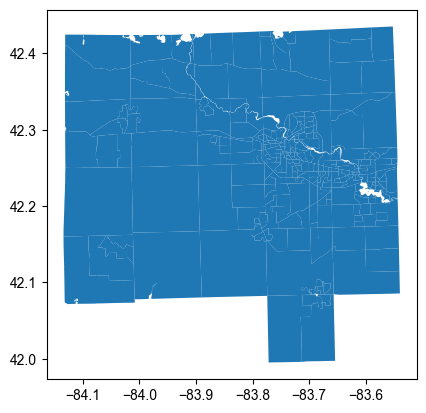

In [31]:
REGION = "washtenaw"

gdf = gpd.read_file("data/semcog/semcog_region-Blockgroup-20251120.geojson")

# gdf is a dataframe of geographical zones represented as MultiPolygons
# extract the centroids and lat/lon bounds of each zone
gdf["lat"] = np.radians(gdf["geometry"].apply(lambda x: x.centroid.coords[0][1]))
gdf["lon"] = np.radians(gdf["geometry"].apply(lambda x: x.centroid.coords[0][0]))
gdf[["lon_min", "lat_min", "lon_max", "lat_max"]] = gdf["geometry"].apply(
    lambda poly: np.radians(pd.Series(poly.bounds)))

# geoID has type object so we convert it to Int64
gdf["geoId"] = gdf["geoId"].astype("Int64")
gdf.plot()

df = pd.read_csv("data/semcog/SEMCOG_Person_Travel_2019_vs_2024_v14-599.csv")

In [8]:
trips = sample_semcog_data(df, gdf)

trips_copy = trips.copy()
trips_copy["pick_lat"] = np.degrees(trips_copy["pick_lat"])
trips_copy["pick_lon"] = np.degrees(trips_copy["pick_lon"])
trips_copy["drop_lat"] = np.degrees(trips_copy["drop_lat"])
trips_copy["drop_lon"] = np.degrees(trips_copy["drop_lon"])
trips_copy.to_parquet(f"output/semcog/{REGION}-trips.parquet")

print(len(trips))
trips.head()

87905680


,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax
0,39853,0.742166,-1.454915,0.741261,-1.454834,2
0,53888,0.742044,-1.455111,0.741649,-1.454792,2
0,52387,0.742131,-1.455064,0.741636,-1.454869,1
0,50572,0.742064,-1.455152,0.741354,-1.454532,1
0,46753,0.742034,-1.455011,0.741431,-1.454627,2


In [9]:
trips_copy.sample(n=200000).to_parquet(f"output/semcog/{REGION}-trips-downsampled.parquet")

In [5]:
assert REGION == "washtenaw"

keplr_df = clip_trips_to_region(df, ANN_ARBOR_ISLAND, keep_radians=False)

keplr_df = keplr_df.sample(n=50000)
keplr_df["created_at"] = pd.to_datetime(keplr_df["created_at"], unit="s", origin="2025-01-01 00:00")

keplr_df.to_parquet("output/semcog/ann-arbor-clipped-trips.parquet")
keplr_df.head()

,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax
970882,2025-01-03 13:29:24,42.295937,-83.687889,42.278744,-83.744049,1
465159,2025-01-05 16:11:18,42.307468,-83.735275,42.236958,-83.734360,1
170731,2025-01-02 03:49:39,42.275661,-83.784264,42.269524,-83.738205,1
1401190,2025-01-01 11:14:55,42.268333,-83.676567,42.288284,-83.721069,1
211949,2025-01-05 07:42:53,42.273067,-83.754227,42.278770,-83.739830,1


In [15]:
assert REGION == "washtenaw"

for mode in ("all", "internal", "inbound", "outbound"):
    keplr_df = snap_trips_to_boundary_points(df, ANN_ARBOR_ISLAND, INTERCHANGES + OVERPASSES,
                                             keep_radians=False, mode=mode)
    print(f"{mode} trips:", len(keplr_df))

    keplr_df["created_at"] = pd.to_datetime(keplr_df["created_at"], unit="s", origin="2025-01-01 00:00")

    keplr_df.to_parquet(f"output/semcog/{mode}-ann-arbor-trips.parquet")
    keplr_df.head()

all trips: 3345419
internal trips: 1930749
inbound trips: 716145
outbound trips: 698525


In [13]:
def vectorized_latlng_to_cell(lat, lon, res: int, is_radians: bool = True):
    if is_radians:
        lat = np.rad2deg(lat)
        lon = np.rad2deg(lon)

    cells = np.vectorize(h3.latlng_to_cell)(lat, lon, res)
    return np.vectorize(h3.str_to_int)(cells)


def preprocess_requests(df: pd.DataFrame):
    df["predicted_lm_dist"] = distance(df["pick_lat"], df["pick_lon"], df["drop_lat"], df["drop_lon"])

    df.sort_values("created_at", inplace=True, ignore_index=True)
    df.reset_index(drop=True, inplace=True)


def preprocess_riders(df):
    df.sort_values("created_at", inplace=True, ignore_index=True)
    df.reset_index(drop=True, inplace=True)

In [30]:
requests = snap_trips_to_boundary_points(df, ANN_ARBOR_ISLAND, INTERCHANGES + OVERPASSES, mode="all")
preprocess_requests(requests)

requests.to_parquet("data/requests/ann-arbor.parquet")

print(requests.dtypes)
print(len(requests))
requests.head()

created_at            uint32
pick_lat             float32
pick_lon             float32
drop_lat             float32
drop_lon             float32
pax                    uint8
pick_hex               int64
drop_hex               int64
predicted_lm_dist    float32
dtype: object
3346447


,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax,pick_hex,drop_hex,predicted_lm_dist
0,0,0.738629,-1.460671,0.738030,-1.461656,1,604233477973344255,604173502378934271,8.217588
1,0,0.737561,-1.462025,0.737482,-1.462059,1,604173502378934271,604173502378934271,1.238919
2,0,0.738694,-1.460979,0.738383,-1.461512,3,604233477973344255,604233477973344255,4.642469
3,1,0.737497,-1.461377,0.737588,-1.461326,1,604173502378934271,604173502378934271,1.365432
4,1,0.737176,-1.461526,0.737830,-1.460710,2,604233474215247871,604233478107561983,7.790916


In [14]:
for n_riders in (7500, 10000, 12500, 15000):
    riders = sample_points_in_polygon(ANN_ARBOR_ISLAND, n_riders, radians=True)
    riders["created_at"] = np.uint32(0)
    riders["lifetime"] = np.uint32(24 * 7 * 3600)
    preprocess_riders(riders, h3_res=H3_RESOLUTION)

    riders.to_parquet(f"data/riders/ann-arbor-{n_riders}.parquet")

print(riders.dtypes)
riders.head()

lat           float32
lon           float32
created_at     uint32
lifetime       uint32
login_hex       int64
dtype: object


,lat,lon,created_at,lifetime,login_hex
0,0.737210,-1.460881,0,604800,604233478107561983
1,0.737573,-1.461891,0,604800,604173502378934271
2,0.737492,-1.460849,0,604800,604233478107561983
3,0.738411,-1.461045,0,604800,604233477973344255
4,0.737688,-1.461394,0,604800,604173502378934271


In [5]:
INTERCHANGES_RAW = [
    {"type": "Polygon", "coordinates": [[[-83.7653053184995, 42.24695964710352], [-83.7653053184995, 42.24509281118205],
                                         [-83.76275861187068, 42.24509281118205],
                                         [-83.76275861187068, 42.24695964710352],
                                         [-83.7653053184995, 42.24695964710352]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.74015017566227, 42.23774097697641], [-83.74015017566227, 42.23605048903499],
         [-83.73792020364262, 42.23605048903499], [-83.73792020364262, 42.23774097697641],
         [-83.74015017566227, 42.23774097697641]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68660719232598, 42.22658232594573], [-83.68660719232598, 42.224802767846434],
         [-83.68424050321555, 42.224802767846434], [-83.68424050321555, 42.22658232594573],
         [-83.68660719232598, 42.22658232594573]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68519752285086, 42.25546774214873], [-83.68519752285086, 42.2537539885268],
         [-83.68270093245769, 42.2537539885268], [-83.68270093245769, 42.25546774214873],
         [-83.68519752285086, 42.25546774214873]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68857539500242, 42.307200975706685], [-83.68857539500242, 42.3054901375886],
         [-83.68609755756299, 42.3054901375886], [-83.68609755756299, 42.307200975706685],
         [-83.68857539500242, 42.307200975706685]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.74855035499152, 42.301261500288085], [-83.74855035499152, 42.29988261363462],
         [-83.74655327973984, 42.29988261363462], [-83.74655327973984, 42.301261500288085],
         [-83.74855035499152, 42.301261500288085]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78825960166517, 42.299086240275884], [-83.78825960166517, 42.29751961679856],
         [-83.78595539072994, 42.29751961679856], [-83.78595539072994, 42.299086240275884],
         [-83.78825960166517, 42.299086240275884]]]}
]

OVERPASSES_RAW = [
    {"type": "Polygon", "coordinates": [
        [[-83.72065443320648, 42.237651471473384], [-83.72065443320648, 42.23686885402677],
         [-83.71965779814654, 42.23686885402677], [-83.71965779814654, 42.237651471473384],
         [-83.72065443320648, 42.237651471473384]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.70013643938798, 42.23263938226738], [-83.70013643938798, 42.23191794854806],
         [-83.69935695982517, 42.23191794854806], [-83.69935695982517, 42.23263938226738],
         [-83.70013643938798, 42.23263938226738]]]},
    {"type": "Polygon", "coordinates": [[[-83.6860436272189, 42.2309475936862], [-83.6860436272189, 42.23024168958983],
                                         [-83.68496888780194, 42.23024168958983],
                                         [-83.68496888780194, 42.2309475936862],
                                         [-83.6860436272189, 42.2309475936862]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68403816600447, 42.24578228019548], [-83.68403816600447, 42.24515231376033],
         [-83.6831281692095, 42.24515231376033], [-83.6831281692095, 42.24578228019548],
         [-83.68403816600447, 42.24578228019548]]]},
    {"type": "Polygon", "coordinates": [[[-83.6831712809513, 42.29502296896619], [-83.6831712809513, 42.29410786241498],
                                         [-83.68209171348968, 42.29410786241498],
                                         [-83.68209171348968, 42.29502296896619],
                                         [-83.6831712809513, 42.29502296896619]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.70828346106319, 42.32429627193206], [-83.70828346106319, 42.323685932804864],
         [-83.70744465315146, 42.323685932804864], [-83.70744465315146, 42.32429627193206],
         [-83.70828346106319, 42.32429627193206]]]},
    {"type": "Polygon", "coordinates": [[[-83.73583255375239, 42.32023765134], [-83.73583255375239, 42.31941550032116],
                                         [-83.73486407734694, 42.31941550032116], [-83.73486407734694, 42.32023765134],
                                         [-83.73583255375239, 42.32023765134]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.76626238447042, 42.2993415694097], [-83.76626238447042, 42.29872522220684],
         [-83.76544945524273, 42.29872522220684], [-83.76544945524273, 42.2993415694097],
         [-83.76626238447042, 42.2993415694097]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.80025005101768, 42.29079492822921], [-83.80025005101768, 42.289853415187515],
         [-83.7988783537706, 42.289853415187515], [-83.7988783537706, 42.29079492822921],
         [-83.80025005101768, 42.29079492822921]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78337787301311, 42.28208581687849], [-83.78485546123454, 42.28208581687849],
         [-83.78485546123454, 42.28107150027606], [-83.78337787301311, 42.28107150027606],
         [-83.78337787301311, 42.28208581687849]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78480983499519, 42.27312583402841], [-83.78480983499519, 42.27226297526143],
         [-83.78384466454183, 42.27226297526143], [-83.78384466454183, 42.27312583402841],
         [-83.78480983499519, 42.27312583402841]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.77661422170391, 42.256574286289904], [-83.77800450587073, 42.256574286289904],
         [-83.77800450587073, 42.255639763725604], [-83.77661422170391, 42.255639763725604],
         [-83.77661422170391, 42.256574286289904]]]},
]

CHARGERS5 = [
    # centre
    {"coordinates": [[[-83.7378897407689, 42.27752162482751], [-83.73482383717868, 42.27752162482751],
                      [-83.73482383717868, 42.275529373109975], [-83.7378897407689, 42.275529373109975],
                      [-83.7378897407689, 42.27752162482751]]]},

    # north
    {"coordinates": [[[-83.71124736424815, 42.306030926087566], [-83.71124736424815, 42.30483429465836],
                      [-83.7092241682606, 42.30483429465836], [-83.7092241682606, 42.306030926087566],
                      [-83.71124736424815, 42.306030926087566]]]},

    # south
    {"coordinates": [[[-83.75139742143158, 42.24628816468756], [-83.75139742143158, 42.24464723904189],
                      [-83.74957850668383, 42.24464723904189], [-83.74957850668383, 42.24628816468756],
                      [-83.75139742143158, 42.24628816468756]]]},

    # east
    {"coordinates": [[[-83.69521399263594, 42.25210742322293], [-83.69521399263594, 42.250498193073106],
                      [-83.6928336426927, 42.250498193073106], [-83.6928336426927, 42.25210742322293],
                      [-83.69521399263594, 42.25210742322293]]]},

    # west
    {"coordinates": [[[-83.77699954277293, 42.27353470926183], [-83.77699954277293, 42.271900498863815],
                      [-83.7749141154144, 42.271900498863815], [-83.7749141154144, 42.27353470926183],
                      [-83.77699954277293, 42.27353470926183]]]}
]

CHARGERS1 = [
    {"type": "Polygon", "coordinates": [
        [[-83.73831640480778, 42.27855981922442], [-83.73831640480778, 42.276014512783334],
         [-83.73457776047084, 42.276014512783334], [-83.73457776047084, 42.27855981922442],
         [-83.73831640480778, 42.27855981922442]]]}
]

CHARGERS2 = [
    {"type": "Polygon", "coordinates": [
        [[-83.74491770063037, 42.2632820193812], [-83.74491770063037, 42.26059114181942],
         [-83.74094736902258, 42.26059114181942], [-83.74094736902258, 42.2632820193812],
         [-83.74491770063037, 42.2632820193812]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.71727466241134, 42.29012175342128], [-83.71727466241134, 42.28719877950635],
         [-83.71350616145824, 42.28719877950635], [-83.71350616145824, 42.29012175342128],
         [-83.71727466241134, 42.29012175342128]]]}
]

radians = True
for interchange in CHARGERS2:
    lons, lats = zip(*interchange["coordinates"][0])
    mean_lon = np.mean(lons)
    mean_lat = np.mean(lats)

    if radians:
        mean_lat = np.deg2rad(mean_lat)
        mean_lon = np.deg2rad(mean_lon)

    print(f"[{mean_lat}, {mean_lon}],")

[0.7376146380678315, -1.4615968275440983],
[0.7380814594589727, -1.4611157745557037],
